# Face Mask Detection System

This project builds a CNN model to detect whether a person is wearing a face mask or not.

- Dataset: Face Mask Dataset (7553 images)
- Model: Convolutional Neural Network (CNN)
- Framework: TensorFlow & Keras

In [1]:
# install libraries
!pip install opencv-python pillow scikit-learn tensorflow

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Loading the Dataset

In [ ]:
# set dataset path
DATASET_PATH = r'C:\Users\PC\Downloads\FaceMaskProject\FaceMaskProject\data'

with_mask_path = os.path.join(DATASET_PATH, 'with_mask') + os.sep
without_mask_path = os.path.join(DATASET_PATH, 'without_mask') + os.sep

with_mask_files = os.listdir(with_mask_path)
without_mask_files = os.listdir(without_mask_path)

print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\FaceMaskProject\\data\\with_mask\\'

## Creating Labels

In [ ]:
# 1 = with mask, 0 = without mask
with_mask_labels = [1]*len(with_mask_files)
without_mask_labels = [0]*len(without_mask_files)

labels = with_mask_labels + without_mask_labels

print('Total labels:', len(labels))
print('First 5:', labels[0:5])
print('Last 5:', labels[-5:])

Total labels: 7554
First 5: [1, 1, 1, 1, 1]
Last 5: [0, 0, 0, 0, 0]


## Displaying Sample Images

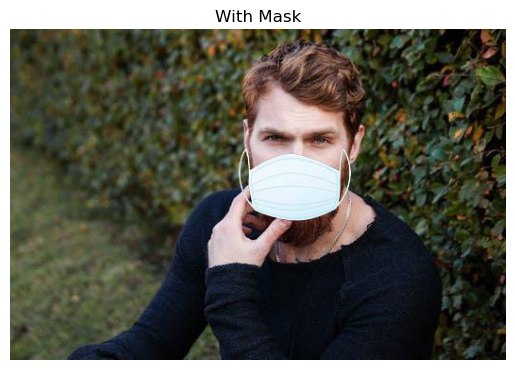

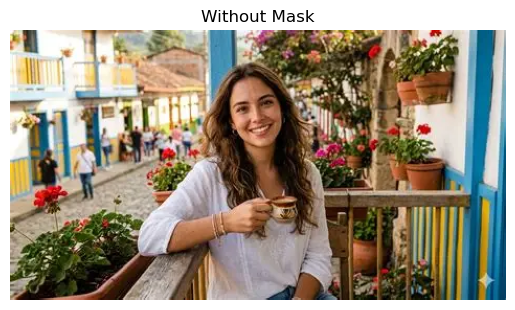

In [ ]:
# display a sample image with mask
img = mpimg.imread(with_mask_path + with_mask_files[0])
plt.imshow(img)
plt.title('With Mask')
plt.axis('off')
plt.show()

# display a sample image without mask
img = mpimg.imread(without_mask_path + without_mask_files[0])
plt.imshow(img)
plt.title('Without Mask')
plt.axis('off')
plt.show()

## Image Processing

In [ ]:
# load saved data if exists, otherwise process images
if os.path.exists('data.npy') and os.path.exists('labels.npy'):
    print('Loading saved data...')
    X = np.load('data.npy')
    Y = np.load('labels.npy')
    print('Data loaded successfully!')
else:
    print('Processing images for the first time...')
    data = []

    for img_file in with_mask_files:
        image = Image.open(with_mask_path + img_file)
        image = image.resize((128,128))
        image = image.convert('RGB')
        image = np.array(image)
        data.append(image)

    for img_file in without_mask_files:
        image = Image.open(without_mask_path + img_file)
        image = image.resize((128,128))
        image = image.convert('RGB')
        image = np.array(image)
        data.append(image)

    X = np.array(data)
    Y = np.array(labels)
    np.save('data.npy', X)
    np.save('labels.npy', Y)
    print('Data saved!')

print('X shape:', X.shape)
print('Y shape:', Y.shape)

Loading saved data...
Data loaded successfully!
X shape: (7553, 128, 128, 3)
Y shape: (7553,)


## Train Test Split

In [ ]:
# split data into 80% train and 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print('Total images:', X.shape[0])
print('Training images:', X_train.shape[0])
print('Testing images:', X_test.shape[0])

# scale pixel values to 0-1
X_train_scaled = X_train/255
X_test_scaled = X_test/255

Total images: 7553
Training images: 6042
Testing images: 1511


## Building the CNN Model

In [ ]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

model.summary()

c:\Users\vp141\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

In [ ]:
# training the model
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - acc: 0.7822 - loss: 0.4719 - val_acc: 0.8678 - val_loss: 0.3184
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 34s 200ms/step - acc: 0.8816 - loss: 0.2962 - val_acc: 0.9074 - val_loss: 0.2345
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - acc: 0.9016 - loss: 0.2470 - val_acc: 0.9223 - val_loss: 0.2178
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 33s 195ms/step - acc: 0.9169 - loss: 0.2148 - val_acc: 0.9306 - val_loss: 0.2167
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 30s 176ms/step - acc: 0.9307 - loss: 0.1797 - val_acc: 0.9372 - val_loss: 0.2074
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 34s 200ms/step - acc: 0.9441 - loss: 0.1532 - val_acc: 0.9322 - val_loss: 0.2101
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 33s 193ms/step - acc: 0.9514 - loss: 0.1321 - val_acc: 0.9240 - val_loss: 0.2365
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 33s 196ms/step - acc: 0.9533 - loss: 0.1256 - val_acc: 0.9207 - val_loss: 0.2451
Epoch 9/10
170/170 ━━━━━━━━━━━━━

## Model Evaluation

In [ ]:
# evaluate the model on test data
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - acc: 0.9365 - loss: 0.1858
Test Accuracy = 0.9364659190177917


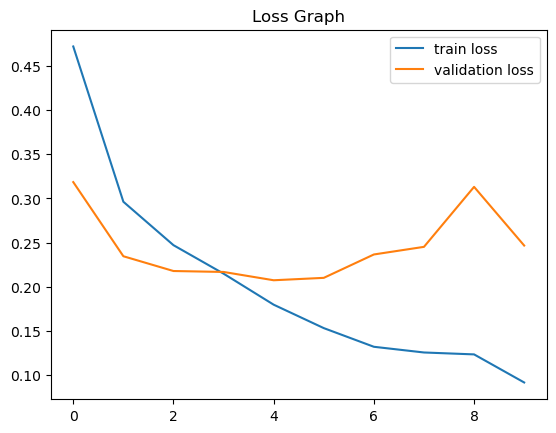

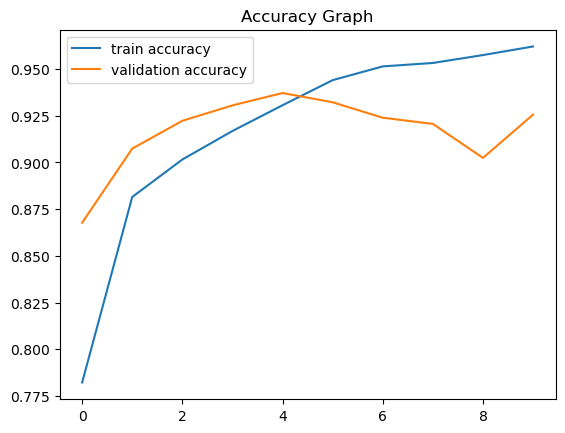

In [ ]:
# plot the loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.title('Loss Graph')
plt.show()

# plot the accuracy
plt.plot(history.history['acc'], label='train accuracy')
plt.plot(history.history['val_acc'], label='validation accuracy')
plt.legend()
plt.title('Accuracy Graph')
plt.show()

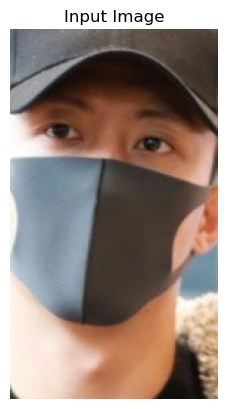

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[0.41948354 0.51234263]]
The person in the image is wearing a mask


In [ ]:
# predicting on a new image
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

# display the image
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
plt.title('Input Image')
plt.axis('off')
plt.show()

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)
print(input_prediction)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')

In [ ]:
# save the model
model.save('face_mask_model.h5')
print('Model saved!')

Model saved!
